In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.nn import CTCLoss
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from typing import Any, Optional, Literal
from collections import OrderedDict
import re
import editdistance

import sys
sys.path.append("..")

from OCR.line_OCR.ctc.models_line_ctc import Decoder
from basic.models import FCN_Encoder
from basic.generic_dataset_manager import OCRDataset, OCRCollateFunction
from basic.utils import edit_wer_from_str, nb_words_from_str, LM_ind_to_str

import matplotlib_inline
%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')

sns.set_theme(style="darkgrid")

In [3]:
def savefig(name, add_pdf=False):
    path = rf"C:\Users\valer\Desktop\mmp_courses\scientific_work\m1p\slides\middle_talk\images\{name}"
    if add_pdf:
        path = path + ".pdf"
    plt.savefig(path, bbox_inches='tight')

In [4]:
class LineVAN(torch.nn.Module):
    def __init__(
        self,
        model_params: dict[str, Any],
        encoder_state_dict: Optional[OrderedDict] = None,
        decoder_state_dict: Optional[OrderedDict] = None
    ):
        super().__init__()
        self.encoder = FCN_Encoder(model_params)
        self.decoder = Decoder(model_params)
        if encoder_state_dict is not None:
            self.encoder.load_state_dict(encoder_state_dict)
        else:
            print("encoder_state_dict is None")
        if decoder_state_dict is not None:
            self.decoder.load_state_dict(decoder_state_dict)
        else:
            print("decoder_state_dict is None")

    def forward(self, x):
        x = self.encoder(x)
        return self.decoder(x)

In [5]:
def get_tokens(params: dict[str, Any], charset: set[str]) -> dict[str, int]:
    """
    see: https://github.com/valerazykov/VerticalAttentionOCR/blob/master/basic/generic_dataset_manager.py#L76
    
    params: dataset_params
    """
    tokens = {
        "pad": params["config"]["padding_token"],
    }
    if params["config"]["charset_mode"].lower() == "ctc":
        tokens["blank"] = len(charset)
        tokens["pad"] = tokens["pad"] if tokens["pad"] else len(charset) + 1
        params["config"]["padding_token"] = tokens["pad"]
    elif params["config"]["charset_mode"] == "attention":
        tokens["end"] = len(charset)
        tokens["start"] = len(charset) + 1
        tokens["pad"] = tokens["pad"] if tokens["pad"] else len(charset) + 2
        if params["config"]["pad_label_with_end_token"]:
            params["config"]["padding_token"] = tokens["end"]
        else:
            params["config"]["padding_token"] = tokens["pad"]

    return tokens

In [6]:
def ctc_remove_successives_identical_ind(ind):
    res = []
    for i in ind:
        if res and res[-1] == i:
            continue
        res.append(i)
    return res

In [7]:
def get_str_xy(x, y, x_len, y_len):
    """
    see compute_metrics func
    """
    batch_size = y.shape[0]
    ind_x = [x[i][:x_len[i]] for i in range(batch_size)]
    ind_y = [y[i][:y_len[i]] for i in range(batch_size)]
    ind_x = [ctc_remove_successives_identical_ind(t) for t in ind_x]
    str_x = [LM_ind_to_str(charset, t, oov_symbol="") for t in ind_x]
    str_y = [LM_ind_to_str(charset, t) for t in ind_y]
    str_x = [re.sub("( )+", ' ', t).strip(" ") for t in str_x]

    return str_x, str_y

In [8]:
device = torch.device(
    "cuda:0" if torch.cuda.is_available()
    else "cpu"
)
device

device(type='cuda', index=0)

## Ансамбль

In [9]:
dataset_path = "../Datasets/formatted/SK_lines"
checkpoint_path = "../OCR/line_OCR/ctc/outputs/SK_line/ensemble/" #"../OCR/line_OCR/ctc/outputs/SK_line_v4_ensemble"  # /i/checkpoints
params_path = "../OCR/line_OCR/ctc/outputs/SK_line/ensemble/"  # i/results/params
labels_path = "../Datasets/formatted/SK_lines/labels.pkl"

In [10]:
with open(labels_path, "rb") as f:
    info = pickle.load(f)
    # charset = set(info["charset"])
    # charset = sorted(list(charset))

In [11]:
with open("charset_500.txt", "r") as f:
    charset = list(f.readline().rstrip())
    charset = set(charset)
    charset = sorted(list(charset))

In [12]:
# with open("charset_500.txt", "w") as f:
#     print("".join(charset), file=f)

In [13]:
gt = info["ground_truth"]
gt["test"]

{'test_0.jpg': {'text': 'Рябчикова'},
 'test_1.jpg': {'text': 'Онъ де жилъ въ работникахъ у купца; укралъ что-то'},
 'test_2.jpg': {'text': 'и тотъ ударилъ его палкою по головѣ отъ чего у него'},
 'test_3.jpg': {'text': 'и сдѣлалась будто бѣлая горячка. Обратясь къ Губер-'},
 'test_4.jpg': {'text': 'натору: B-fr! Prens-le, А pince-le! - Слушаюсь.'},
 'test_5.jpg': {'text': 'Болѣе никакихъ распоряженій и не было сдѣлано.-. Впрочемъ'},
 'test_6.jpg': {'text': 'и часовые возвратились на прежніе мѣста - ибо'},
 'test_7.jpg': {'text': 'въ противномъ случаѣ и острожные остались бы безъ'},
 'test_8.jpg': {'text': 'всякаго караула.'},
 'test_9.jpg': {'text': 'Вечеромъ читалъ піэссу - Дядѣ чрезвычайно'},
 'test_10.jpg': {'text': 'понравилась - Беккеру также.'},
 'test_11.jpg': {'text': '10-го утромъ выѣхалъ въ Алексѣевское. Ночевалъ въ'},
 'test_12.jpg': {'text': 'Болотскомъ.'},
 'test_13.jpg': {'text': '1856. Годъ. Май'},
 'test_14.jpg': {'text': '21. 22. 23-е. 24. 25. 26-е. Въ Воскресенскомъ.

In [14]:
MIN_HEIGHT = 130 #139
MIN_WIDTH = 1650


with open(Path(params_path) / f"{1}/results/params", 'r') as params_file:
    params = json.load(params_file)

# делаем паддинг изображений, чтобы приблизить размеры к тому, что было на обучении
dataset_params = params["dataset_params"]
if "padding" not in dataset_params["config"]["constraints"]:
    print("Add padding")
    dataset_params["config"]["constraints"].append("padding")
    dataset_params["config"]["padding"] = {}
dataset_params["config"]["padding"]["min_height"] = MIN_HEIGHT
dataset_params["config"]["padding"]["min_width"] = MIN_WIDTH

test_dataset = OCRDataset(
    dataset_params,
    "test",
    "SK-test",
    [{
        "path": dataset_path,
        "set_name": "test"
    }]
)

test_dataset.charset = charset
test_dataset.tokens = get_tokens(params["dataset_params"], charset)
test_dataset.convert_labels()

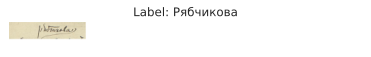

In [15]:
plt.imshow(test_dataset[0]["img"].astype("int"))
plt.title(f"Label: {test_dataset[0]['label']}")
plt.axis("off")
plt.show()

In [16]:
def get_loader(set_name: Literal["train", "valid", "test"], batch_size: int = 1) -> DataLoader:
    dataset = OCRDataset(
        dataset_params,
        "test",  # тут пишем test, чтобы не было аугментации
        "SK-test",
        [{
            "path": dataset_path,
            "set_name": set_name
        }]
    )
    
    dataset.charset = charset
    dataset.tokens = get_tokens(dataset_params, charset)
    dataset.convert_labels()

    collate_fn = OCRCollateFunction(dataset_params["config"])
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=dataset_params["num_gpu"],
        pin_memory=True,
        drop_last=False,
        collate_fn=collate_fn
    )

    return loader

In [17]:
N_MODELS = 6

models = []

for i in range(1, N_MODELS + 1):
    with open(Path(params_path) / f"{i}/results/params", 'r') as params_file:
        params = json.load(params_file)
    checkpoint_path_i = Path(checkpoint_path) / f"{i}/checkpoints"
    checkpoint_name = sorted(os.listdir(checkpoint_path_i))[0]
    print(f"{i}: loading {checkpoint_name}")
    checkpoint = torch.load(checkpoint_path_i / checkpoint_name, weights_only=False)
    models.append(
        LineVAN(
            params["model_params"],
            encoder_state_dict=checkpoint["encoder_state_dict"],
            decoder_state_dict=checkpoint["decoder_state_dict"]
        ).to(device)
    )

1: loading best_10000.pt
2: loading best_9762.pt
3: loading best_9282.pt
4: loading best_10000.pt
5: loading best_9948.pt
6: loading best_9768.pt


In [18]:
test_loader = get_loader("test")
val_loader = get_loader("valid")
train_loader = get_loader("train")

In [19]:
def get_errors(loader):
    for model in models:
        model.eval()
    
    cers_global = [0] * N_MODELS
    n_chars_gt = [0] * N_MODELS
    wers_global = [0] * N_MODELS
    n_words_gt = [0] * N_MODELS
    
    with torch.no_grad():
        for ind_batch, batch_data in enumerate(tqdm(loader)):
            x = batch_data["imgs"].to(device)
            y = batch_data["labels"].to(device)
            x_reduced_len = [s[1] for s in batch_data["imgs_reduced_shape"]]
            y_len = batch_data["labels_len"]
            
            #loss_ctc = CTCLoss(blank=test_dataset.tokens["blank"], reduction="sum")
            str_x_list = []
            cer_list = []
            for i, model in enumerate(models):
                global_pred = model(x)
                #loss = loss_ctc(global_pred.permute(2, 0, 1), y, x_reduced_len, y_len)
                pred = torch.argmax(global_pred, dim=1).cpu().numpy()
        
                str_x, str_y = get_str_xy(pred, y.cpu().numpy(), x_reduced_len, y_len)
                
                str_x = str_x[0]
                str_y = str_y[0]
                edit = editdistance.eval(str_y, str_x)
                cers_global[i] += edit
                n_chars_gt[i] += len(str_y)
                wers_global[i] += edit_wer_from_str(str_y, str_x)
                n_words_gt[i] += nb_words_from_str(str_y)
    
                cer_list.append(edit / len(str_y))
    
                str_x_list.append(str_x)
            # plt.figure(figsize=(20, 30))
            # plt.imshow(test_dataset[ind_batch]["img"])
            # plt.axis("off")
            # plt.title(f"gt: {str_y}\n" + "\n".join([f"Pred {i + 1}: {str_x_list[i]} (cer: {cer_list[i] * 100: .1f}%)" for i in range(N_MODELS)]), fontsize=20)
            # plt.show()

    cers = [cers_global[i] / n_chars_gt[i] for i in range(N_MODELS)]
    wers = [wers_global[i] / n_words_gt[i] for i in range(N_MODELS)]
    return cers, wers

In [20]:
train_cers, train_wers = get_errors(train_loader)
train_cers, train_wers

100%|██████████| 2667/2667 [00:41<00:00, 64.26it/s]


([0.33942145544169156,
  0.3739006356207031,
  0.3317161758983007,
  0.33460457473948196,
  0.4002853807238293,
  0.3456911834652138],
 [0.5900109546800828,
  0.6741185539822291,
  0.6024668316630827,
  0.5587698299995942,
  0.698381141721102,
  0.6234835882663204])

In [21]:
val_cers, val_wers = get_errors(val_loader)
val_cers, val_wers

100%|██████████| 123/123 [00:01<00:00, 66.15it/s]


([0.3156869688385269,
  0.32878895184135976,
  0.30789660056657225,
  0.31586402266288954,
  0.3286118980169972,
  0.29621104815864024],
 [0.7101584342963654,
  0.7166821994408201,
  0.6971109040074557,
  0.7148182665424044,
  0.7204100652376515,
  0.706430568499534])

In [22]:
test_cers, test_wers = get_errors(test_loader)
test_cers, test_wers

100%|██████████| 86/86 [00:01<00:00, 60.39it/s]


([0.2851465474416294,
  0.2965722801788376,
  0.27595628415300544,
  0.2776949826130154,
  0.29135618479880776,
  0.27148534525583706],
 [0.600470035252644,
  0.6145710928319624,
  0.6298472385428907,
  0.5957696827262045,
  0.6133960047003525,
  0.6039952996474736])

### Усреднение вероятностей

In [41]:
def get_ensemble_pred(models, x):
    probs = []
    for model in models:
        prob = torch.exp(model(x))
        probs.append(prob.cpu().numpy())
    
    ens_prob = np.mean(np.array(probs), axis=0)
    return np.argmax(ens_prob, axis=1)

In [44]:
def get_ensemble_errors(loader):
    for model in models:
        model.eval()
    
    cer_global = 0
    n_chars_gt = 0
    wer_global = 0
    n_words_gt = 0
    
    with torch.no_grad():
        for ind_batch, batch_data in enumerate(tqdm(loader)):
            x = batch_data["imgs"].to(device)
            y = batch_data["labels"].to(device)
            x_reduced_len = [s[1] for s in batch_data["imgs_reduced_shape"]]
            y_len = batch_data["labels_len"]
            
            pred = get_ensemble_pred(models, x)
            str_x, str_y = get_str_xy(pred, y.cpu().numpy(), x_reduced_len, y_len)
            
            str_x = str_x[0]
            str_y = str_y[0]
            edit = editdistance.eval(str_y, str_x)
            cer_global += edit
            n_chars_gt += len(str_y)
            wer_global += edit_wer_from_str(str_y, str_x)
            n_words_gt += nb_words_from_str(str_y)

    cer_ens_prob = cer_global / n_chars_gt
    wer_ens_prob = wer_global / n_words_gt
    return cer_ens_prob, wer_ens_prob

In [25]:
cer_ens_prob, wer_ens_prob = get_ensemble_errors(train_loader)
print("Train ens metrics")
print(f"CER = {cer_ens_prob}")
print(f"WER = {wer_ens_prob}")

100%|██████████| 2667/2667 [00:38<00:00, 69.74it/s]

Train ens metrics
CER = 0.3324080079560687
WER = 0.6063618290258449


In [26]:
np.min(train_cers), np.mean(train_cers), np.min(train_wers), np.mean(train_wers)

(0.3317161758983007,
 0.3542699009815367,
 0.5587698299995942,
 0.6245384833854019)

In [27]:
cer_ens_prob, wer_ens_prob = get_ensemble_errors(val_loader)
print("Valid ens metrics")
print(f"CER = {cer_ens_prob}")
print(f"WER = {wer_ens_prob}")

100%|██████████| 123/123 [00:01<00:00, 67.48it/s]

Valid ens metrics
CER = 0.334985835694051
WER = 0.7194780987884436


In [28]:
np.min(val_cers), np.mean(val_cers), np.min(val_wers), np.mean(val_wers)

(0.29621104815864024,
 0.3155099150141643,
 0.6971109040074557,
 0.7109350730040385)

In [29]:
cer_ens_prob, wer_ens_prob = get_ensemble_errors(test_loader)
print("Test ens metrics")
print(f"CER = {cer_ens_prob}")
print(f"WER = {wer_ens_prob}")

100%|██████████| 86/86 [00:01<00:00, 66.57it/s]

Test ens metrics
CER = 0.2985593641331346
WER = 0.618096357226792


In [30]:
np.min(test_cers), np.mean(test_cers), np.min(test_wers), np.mean(test_wers)

(0.27148534525583706,
 0.2830352707401888,
 0.5957696827262045,
 0.609674892283588)

### Неопределенность

In [31]:
def calculate_uncertainty(predictions: list[str]) -> float:
    """
    Рассчитывает неопределенность как средний CER между предсказаниями разных моделей.
    """
    n_models = len(predictions)
    total_distance = 0
    num_comparisons = 0

    # Вычисляем пару CER между предсказаниями каждой модели
    for i in range(n_models):
        for j in range(i + 1, n_models):
            total_distance += editdistance.eval(predictions[i], predictions[j]) / max(len(predictions[i]), len(predictions[j]))
            num_comparisons += 1

    # Возвращаем среднее значение CER
    return total_distance / num_comparisons


def get_uncertainty_scores(loader):

    uncertainty_scores = []
    
    # Получаем предсказания всех моделей
    with torch.no_grad():
        for ind_batch, batch_data in enumerate(tqdm(loader)):
            x = batch_data["imgs"].to(device)
            y = batch_data["labels"].to(device)
            x_reduced_len = [s[1] for s in batch_data["imgs_reduced_shape"]]
            y_len = batch_data["labels_len"]
            
            str_x_list = []
            cers_per_model = []
    
            # Проходим по всем моделям и собираем предсказания
            for i, model in enumerate(models):
                global_pred = model(x)
                pred = torch.argmax(global_pred, dim=1).cpu().numpy()
                str_x, str_y = get_str_xy(pred, y.cpu().numpy(), x_reduced_len, y_len)
                str_x = str_x[0]
                str_y = str_y[0]
                str_x_list.append(str_x)  # Предсказанная строка от модели
    
                cer = editdistance.eval(str_y, str_x) / len(str_y)
                cers_per_model.append(cer)
    
            # Рассчитываем неопределенность для текущей строки
            uncertainty = calculate_uncertainty(str_x_list)
    
            # Сохраняем результаты: исходная строка, предсказания и её неопределенность
            uncertainty_scores.append((str_y, str_x_list, uncertainty, cers_per_model))

    return uncertainty_scores

In [32]:
train_uncertainty_scores = get_uncertainty_scores(train_loader)
val_uncertainty_scores = get_uncertainty_scores(val_loader)
test_uncertainty_scores = get_uncertainty_scores(test_loader)

100%|██████████| 86/86 [00:01<00:00, 64.86it/s]


In [49]:
# Test uncertainty top

# Ранжируем строки по неопределенности (от самой неопределённой к наименее)
uncertainty_scores = sorted(test_uncertainty_scores, key=lambda x: x[2], reverse=True)

# Выводим строки с наибольшей неопределенностью
for original, preds, uncertainty, cers in uncertainty_scores:
    print(f"GT     : {original}")
    for i, (pred, cer) in enumerate(zip(preds, cers)):
        print(f"Model {i + 1}: {pred} | (CER = {cer * 100:.2f}%)")
    print(f"Uncertainty (avg CER between models): {uncertainty}")
    print(f"Average CER: {np.mean(cers) * 100 :.2f}%")
    print()

GT     : мебели, картинъ, бронзу. Если я гдѣ-нибудь буду жить въ Россіи - такъ
Model 1: . Маебиляи, картимъ, бронцу. Ястия пдѣ твудь буду жинь крFеж дасіе - наяъ | (CER = 40.58%)
Model 2: - Мевилы, Картимъ. Оброшъцу - Четид дъ тибудѣ буду жиеть кедоесчій намъ | (CER = 53.62%)
Model 3: 8-з. Минбили, каршимъ, Гроицу. ЯСстичя пцѣтвбудъ буду житъ кУеодесій талъ | (CER = 50.72%)
Model 4: Мабили, Картшинъ, бтроицу. Яатая щцѣствудѣ буду жинь кредескіе - шеая | (CER = 46.38%)
Model 5: 49мавили; картичъ. броицу. ЯЭта дъ пцв твурдъ бузду pинтъ кУі десчіnю ;я;на | (CER = 62.32%)
Model 6: 289дf4я. Манвили, Картимъ, Бронцу. ЯСстъ ъ чуѣ тбудѣ буду жичнь р(ОДдесіn таïъ8 | (CER = 60.87%)
Uncertainty (avg CER between models): 0.45497292267564116
Average CER: 52.42%

GT     : натору: B-fr! Prens-le, А pince-le! - Слушаюсь.
Model 1: паптору. В.- Р9 рошдъ въ, 3ѣ рніисe lNO. Сленноюіѣ. | (CER = 72.34%)
Model 2: пахтору. В-ру рошодъ въ, 3ѣ ріиe 6e. 4. Слиноюоіѣ. | (CER = 70.21%)
Model 3: натору. В.- Pf рашо

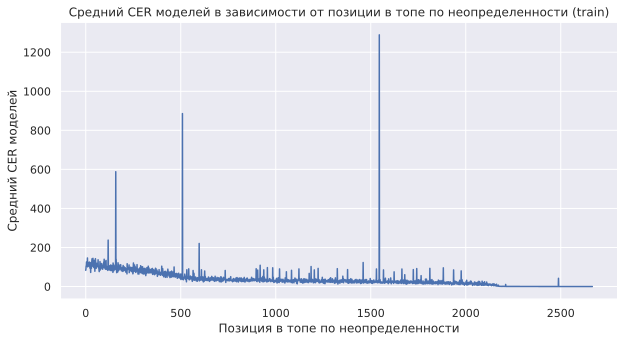

In [50]:
uncertainty_scores = sorted(train_uncertainty_scores, key=lambda x: x[2], reverse=True)
# uncertainty_scores = [x for x in uncertainty_scores if np.max(x[3]) <= 1]
# uncertainty_scores = uncertainty_scores[:-500]
mean_cers = []
for original, preds, uncertainty, cers in uncertainty_scores:
    mean_cers.append(np.mean(cers) * 100)

plt.figure(figsize=(10, 5))
plt.plot(mean_cers)
plt.title("Средний CER моделей в зависимости от позиции в топе по неопределенности (train)")
plt.xlabel("Позиция в топе по неопределенности")
plt.ylabel("Средний CER моделей")
plt.savefig("./ensemble_uncertainty_lev_500_train.pdf", bbox_inches='tight')
plt.show()

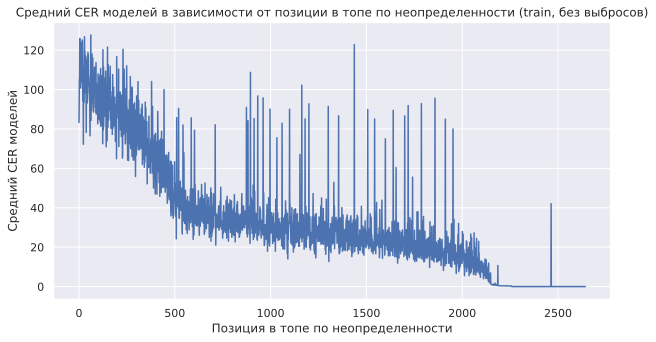

In [64]:
uncertainty_scores = sorted(train_uncertainty_scores, key=lambda x: x[2], reverse=True)
uncertainty_scores = [x for x in uncertainty_scores if np.max(x[3]) <= 1.5]
# uncertainty_scores = uncertainty_scores[:-500]
mean_cers = []
for original, preds, uncertainty, cers in uncertainty_scores:
    mean_cers.append(np.mean(cers) * 100)

plt.figure(figsize=(10, 5))
plt.plot(mean_cers)
plt.title("Средний CER моделей в зависимости от позиции в топе по неопределенности (train, без выбросов)")
plt.xlabel("Позиция в топе по неопределенности")
plt.ylabel("Средний CER моделей")
plt.savefig("./ensemble_uncertainty_lev_500_train_clean.pdf", bbox_inches='tight')
plt.show()

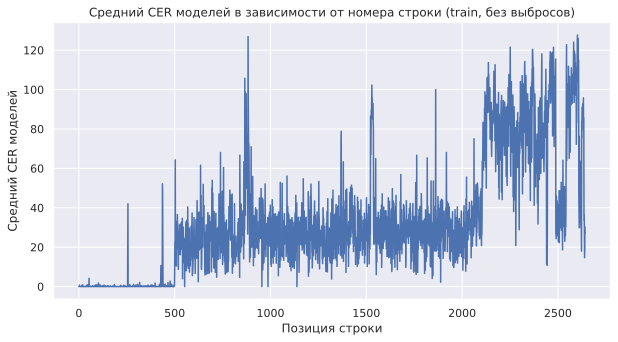

In [80]:
# uncertainty_scores = sorted(train_uncertainty_scores, key=lambda x: x[2], reverse=True)
uncertainty_scores = [x for x in train_uncertainty_scores if np.max(x[3]) <= 1.5]
# uncertainty_scores = uncertainty_scores[:-500]
mean_cers = []
for original, preds, uncertainty, cers in uncertainty_scores:
    mean_cers.append(np.mean(cers) * 100)

plt.figure(figsize=(10, 5))
plt.plot(mean_cers)
plt.title("Средний CER моделей в зависимости от номера строки (train, без выбросов)")
plt.xlabel("Позиция строки")
plt.ylabel("Средний CER моделей")
plt.savefig("./ensemble_avg_cer_500_train_clean_no_sort.pdf", bbox_inches='tight')
plt.show()

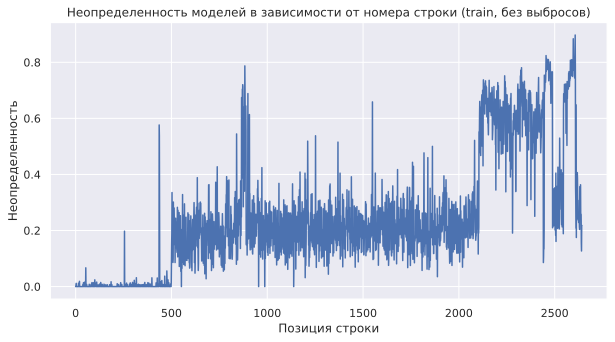

In [81]:
# uncertainty_scores = sorted(train_uncertainty_scores, key=lambda x: x[2], reverse=True)
uncertainty_scores = [x for x in train_uncertainty_scores if np.max(x[3]) <= 1.5]
# uncertainty_scores = uncertainty_scores[:-500]
uncertainty_list = [uncertainty for original, preds, uncertainty, cers in uncertainty_scores]

plt.figure(figsize=(10, 5))
plt.plot(uncertainty_list)
plt.title("Неопределенность моделей в зависимости от номера строки (train, без выбросов)")
plt.xlabel("Позиция строки")
plt.ylabel("Неопределенность")
plt.savefig("./ensemble_uncertainty_lev_500_train_clean_no_sort.pdf", bbox_inches='tight')
plt.show()

In [86]:
# train_uncertainty_array = np.array([uncertainty for original, preds, uncertainty, cers in train_uncertainty_scores])
# np.save("train_uncertainty_500.npy", train_uncertainty_array)

In [88]:
train_uncertainty_500 = np.load("train_uncertainty_500.npy")
train_uncertainty_500.shape

(2667,)

In [103]:
using_train_idx = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 739, 840, 866, 867, 868, 870, 871, 872, 873, 874, 876, 877, 878, 879, 880, 882, 883, 884, 885, 886, 887, 888, 889, 899, 907, 972, 1172, 1212, 1253, 1370, 1551, 1566, 1682, 1760, 1765, 1820, 1840, 1864, 2084, 2107, 2108, 2109, 2110, 2111, 2112, 2113, 2114, 2115, 2116, 2117, 2118, 2119, 2120, 2121, 2122, 2123, 2124, 2125, 2126, 2127, 2128, 2129, 2130, 2131, 2132, 2133, 2134, 2135, 2136, 2137, 2138, 2139, 2140, 2141, 2142, 2143, 2144, 2145, 2146, 2147, 2148, 2149, 2150, 2151, 2152, 2153, 2154, 2155, 2156, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2164, 2165, 2166, 2167, 2168, 2169, 2170, 2171, 2172, 2173, 2174, 2175, 2176, 2177, 2178, 2179, 2180, 2181, 2182, 2183, 2184, 2185, 2186, 2187, 2188, 2189, 2190, 2191, 2192, 2193, 2194, 2195, 2196, 2198, 2199, 2200, 2201, 2202, 2203, 2204, 2205, 2206, 2207, 2208, 2209, 2210, 2211, 2212, 2213, 2214, 2215, 2216, 2217, 2218, 2219, 2220, 2221, 2222, 2223, 2224, 2225, 2226, 2227, 2228, 2229, 2230, 2231, 2232, 2233, 2234, 2235, 2236, 2237, 2238, 2239, 2240, 2241, 2242, 2243, 2244, 2245, 2246, 2247, 2248, 2249, 2250, 2252, 2253, 2254, 2255, 2256, 2257, 2258, 2259, 2260, 2261, 2262, 2263, 2264, 2265, 2266, 2267, 2268, 2269, 2270, 2271, 2272, 2273, 2274, 2276, 2277, 2278, 2279, 2280, 2281, 2282, 2283, 2284, 2285, 2288, 2289, 2290, 2291, 2292, 2293, 2294, 2295, 2296, 2297, 2298, 2299, 2300, 2301, 2302, 2305, 2306, 2307, 2308, 2309, 2310, 2311, 2312, 2313, 2314, 2315, 2316, 2317, 2318, 2319, 2320, 2321, 2322, 2323, 2324, 2325, 2326, 2327, 2328, 2329, 2330, 2331, 2332, 2333, 2334, 2335, 2336, 2337, 2338, 2339, 2340, 2341, 2342, 2343, 2344, 2345, 2346, 2347, 2348, 2349, 2350, 2351, 2352, 2353, 2354, 2355, 2356, 2357, 2358, 2359, 2360, 2361, 2362, 2363, 2365, 2366, 2367, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377, 2378, 2379, 2380, 2381, 2382, 2383, 2385, 2386, 2387, 2388, 2389, 2390, 2391, 2392, 2393, 2394, 2395, 2396, 2397, 2398, 2399, 2400, 2401, 2402, 2403, 2405, 2406, 2407, 2408, 2409, 2410, 2411, 2412, 2413, 2414, 2415, 2416, 2417, 2418, 2419, 2420, 2421, 2422, 2423, 2424, 2425, 2426, 2427, 2428, 2429, 2430, 2431, 2432, 2433, 2434, 2435, 2436, 2437, 2438, 2439, 2440, 2441, 2442, 2443, 2444, 2445, 2446, 2447, 2448, 2449, 2450, 2456, 2457, 2458, 2459, 2460, 2461, 2462, 2463, 2464, 2465, 2466, 2467, 2468, 2469, 2470, 2471, 2472, 2473, 2474, 2475, 2476, 2477, 2478, 2479, 2480, 2481, 2482, 2483, 2484, 2485, 2486, 2487, 2488, 2489, 2490, 2491, 2492, 2493, 2494, 2495, 2496, 2497, 2498, 2499, 2500, 2501, 2502, 2503, 2504, 2533, 2542, 2543, 2550, 2558, 2562, 2563, 2564, 2565, 2566, 2567, 2568, 2569, 2570, 2571, 2572, 2573, 2574, 2575, 2576, 2577, 2578, 2579, 2580, 2581, 2582, 2583, 2584, 2585, 2586, 2587, 2588, 2589, 2590, 2591, 2592, 2593, 2594, 2595, 2596, 2597, 2598, 2599, 2600, 2601, 2602, 2603, 2604, 2605, 2606, 2607, 2608, 2609, 2610, 2611, 2612, 2613, 2614, 2615, 2616, 2617, 2618, 2619, 2620, 2621, 2622, 2623, 2624, 2625, 2626, 2627, 2628, 2629, 2630, 2631, 2635, 2637, 2641]

In [104]:
len(using_train_idx), len(set(using_train_idx))

(1000, 1000)

In [106]:
(using_train_idx[:500] == np.arange(500)).all()

True

In [111]:
top_500_uncertainty_idx = np.argsort(-train_uncertainty_500[500:])[:500] + 500

In [115]:
(using_train_idx[500:] == np.array(sorted(top_500_uncertainty_idx))).all()

True

In [93]:
# top_500_uncertainty_idx =  np.argsort(-train_uncertainty_500)[:500]
# np.save("top_500_uncertainty_idx.npy", top_500_uncertainty_idx)

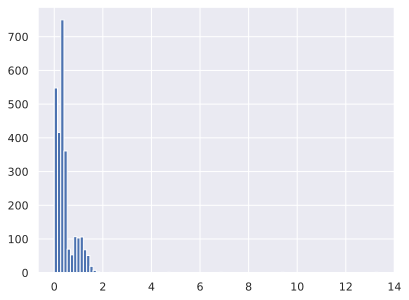

In [53]:
plt.hist([np.max(x[3]) for x in train_uncertainty_scores], bins=100)
plt.show()

In [73]:
outliers = [x for x in train_uncertainty_scores if np.max(x[3]) > 1.5]
outliers = sorted(outliers, key=lambda x: np.max(x[3]), reverse=True)
len(outliers)

24

In [89]:
outliers_u = [x[2] for x in outliers]
outliers_u

[0.180001935733643,
 0.3908010048143706,
 0.6902484620887911,
 0.7154761904761904,
 0.32034847655537313,
 0.8100903246266503,
 0.7824690885880742,
 0.7544863881678526,
 0.8034018127087434,
 0.7709907887033995,
 0.72383261409083,
 0.7307206709296987,
 0.7314313944761707,
 0.7867511154002963,
 0.6894099174081917,
 0.7276093401424026,
 0.7759454334343534,
 0.7794064970376517,
 0.7731502058692582,
 0.7331701074438384,
 0.7693477622451871,
 0.7772581495209606,
 0.7856808096324225,
 0.7954359449609669]

In [74]:
outliers

[('еще',
  ['который не соня знакъ восклищамтѣ. Музке',
   'который +не сать знакъ восклицащъ. Лухьке',
   'который сле соть знакъ восклицамѣ. Лузоки',
   'который не сотя знакъ восклицамтѣ. Музькие',
   'который сне соть знакъ восклинщамъ. Музрке',
   'который Nе соть знакъ восклицамъ. Луфьке'],
  0.180001935733643,
  [12.333333333333334,
   12.666666666666666,
   13.333333333333334,
   13.333333333333334,
   13.0,
   12.666666666666666]),
 ('шуркали',
  ['шеной тровою, ттѣ мѣтрню и пихъ зѣзчаги кослы; - я пошелъ иржомъ',
   'нѣчгной травою, иедяъ мѣжно стихо дур салю коль. - въ пошелъ оратимъ',
   '-зшешой травогю, нѣ мѣжню а пихо Pf9гаи кочь; - яъ пошелъ ирошлъ',
   'шенной травогю, тѣъ мѣтно и пихо, здучаліи кослы; - яъ пошелъ пжоитъ',
   'шегшой травою, иптъ мѣтно и стихо Pfчали колы,; - я пошелъ иерашивъ',
   '84. шечной травоно, телъ лѣтно пихо зffрсатю кось, - Къe пошелъ пратихъ'],
  0.3908010048143706,
  [8.428571428571429,
   9.0,
   8.428571428571429,
   9.0,
   8.8571428571

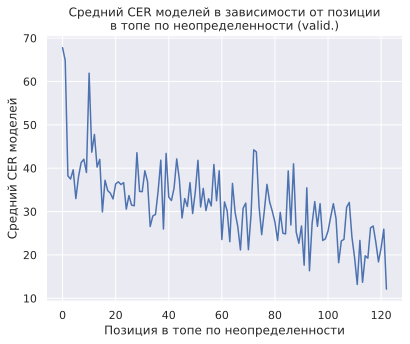

In [62]:
uncertainty_scores = sorted(val_uncertainty_scores, key=lambda x: x[2], reverse=True)
mean_cers = []
for original, preds, uncertainty, cers in uncertainty_scores:
    mean_cers.append(np.mean(cers) * 100)

#plt.figure(figsize=(10, 10))
plt.plot(mean_cers)
plt.title("Средний CER моделей в зависимости от позиции\nв топе по неопределенности (valid.)")
plt.xlabel("Позиция в топе по неопределенности")
plt.ylabel("Средний CER моделей")
plt.savefig("./ensemble_uncertainty_lev_500_val.pdf", bbox_inches='tight')
plt.show()

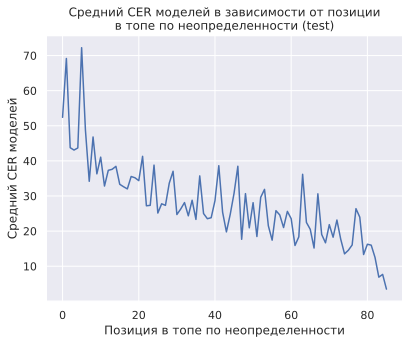

In [63]:
uncertainty_scores = sorted(test_uncertainty_scores, key=lambda x: x[2], reverse=True)
mean_cers = []
for original, preds, uncertainty, cers in uncertainty_scores:
    mean_cers.append(np.mean(cers) * 100)

#plt.figure(figsize=(10, 10))
plt.plot(mean_cers)
plt.title("Средний CER моделей в зависимости от позиции\nв топе по неопределенности (test)")
plt.xlabel("Позиция в топе по неопределенности")
plt.ylabel("Средний CER моделей")
plt.savefig("./ensemble_uncertainty_lev_500_test.pdf", bbox_inches='tight')
plt.show()